# PYPL-like анализ популярности языков программирования через Yandex Wordstat

В этом ноутбуке проводится анализ уже загруженных данных из Yandex Wordstat и их сравнение с данными официального индекса PYPL.

## 1. Импорт библиотек

Подключаем библиотеки для работы с таблицами и графиками.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Пути к файлам проекта

Указываем пути к CSV-файлам Wordstat, итоговому рейтингу и эталонной таблице PYPL.

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"

RAW_DATA_PATH = DATA_DIR / "wordstat_dynamics_raw.csv"
MONTHLY_INDEX_PATH = DATA_DIR / "wordstat_monthly_index.csv"
LATEST_RANKING_PATH = DATA_DIR / "wordstat_latest_ranking.csv"
PYPL_REFERENCE_PATH = DATA_DIR / "pypl_reference.csv"

RAW_DATA_PATH, MONTHLY_INDEX_PATH, LATEST_RANKING_PATH, PYPL_REFERENCE_PATH

(PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_dynamics_raw.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_monthly_index.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_latest_ranking.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/pypl_reference.csv'))

## 3. Загрузка сырых данных Wordstat

Файл `wordstat_dynamics_raw.csv` содержит помесячную динамику tutorial-запросов по выбранным языкам.

In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["date"] = pd.to_datetime(raw_df["date"], utc=True).dt.tz_localize(None)
raw_df.head()

,language,phrase,date,count,share,period,from_date,to_date,devices
0,Python,python tutorial,2018-01-01,299,0.000004,monthly,2018-01-01,2026-04-30,all
1,Python,python tutorial,2018-02-01,435,0.000006,monthly,2018-01-01,2026-04-30,all
2,Python,python tutorial,2018-03-01,435,0.000005,monthly,2018-01-01,2026-04-30,all
3,Python,python tutorial,2018-04-01,465,0.000006,monthly,2018-01-01,2026-04-30,all
4,Python,python tutorial,2018-05-01,393,0.000005,monthly,2018-01-01,2026-04-30,all


## 4. Проверка структуры сырых данных

In [4]:
print(raw_df.shape)
print(raw_df.columns.tolist())
print(sorted(raw_df['language'].unique().tolist()))

(600, 9)
['language', 'phrase', 'date', 'count', 'share', 'period', 'from_date', 'to_date', 'devices']
['Go', 'Java', 'JavaScript', 'Kotlin', 'Python', 'Rust']


## 5. Методология исследования

Исследование построено по аналогии с PYPL:

1. Для каждого языка выбирается tutorial-запрос.
2. Для каждого месяца берется число таких запросов.
3. Для каждого месяца частота языка делится на частоту `java tutorial`.
4. Полученные относительные значения нормализуются до 100%.
5. Доля сглаживается с помощью 6-месячного среднего.
6. Затем результат сравнивается с официальными данными PYPL.

То есть это не официальный индекс PYPL, а PYPL-like индекс на основе Yandex Wordstat.

## 6. Загрузка готового помесячного индекса Wordstat

In [5]:
monthly_index_df = pd.read_csv(MONTHLY_INDEX_PATH)
monthly_index_df["date"] = pd.to_datetime(monthly_index_df["date"], utc=True).dt.tz_localize(None)
monthly_index_df.head()

,language,phrase,date,count,share,java_count,relative_to_java,relative_total,share_pct,smoothed_share_pct,count_change_pct
0,Go,golang tutorial,2018-01-01,27,3.475969e-07,619,0.043619,1.764136,2.4725,2.4725,NaN
1,Java,java tutorial,2018-01-01,619,7.968982e-06,619,1.000000,1.764136,56.6850,56.6850,NaN
2,JavaScript,javascript tutorial,2018-01-01,108,1.390388e-06,619,0.174475,1.764136,9.8901,9.8901,NaN
3,Kotlin,kotlin tutorial,2018-01-01,17,2.188573e-07,619,0.027464,1.764136,1.5568,1.5568,NaN
4,Python,python tutorial,2018-01-01,299,3.849314e-06,619,0.483037,1.764136,27.3810,27.3810,NaN


## 7. Последний рейтинг Wordstat

In [6]:
latest_ranking_df = pd.read_csv(LATEST_RANKING_PATH)
latest_ranking_df["date"] = pd.to_datetime(latest_ranking_df["date"], utc=True).dt.tz_localize(None)
latest_ranking_df

,language,phrase,date,count,share,java_count,relative_to_java,relative_total,share_pct,smoothed_share_pct,count_change_pct,average_share_pct,yearly_trend_pp
0,Python,python tutorial,2026-04-01,510,4.524076e-06,225,2.266667,4.333333,52.3077,52.7022,-0.9709,51.4232,-1.7772
1,Java,java tutorial,2026-04-01,225,1.995916e-06,225,1.000000,4.333333,23.0769,20.9727,-1.3158,29.5538,0.5087
2,Go,golang tutorial,2026-04-01,90,7.983664e-07,225,0.400000,4.333333,9.2308,4.7075,63.6364,3.2314,-0.1511
3,Rust,rust tutorial,2026-04-01,78,6.919175e-07,225,0.346667,4.333333,8.0000,13.0749,-40.4580,5.1363,2.2647
4,JavaScript,javascript tutorial,2026-04-01,37,3.282173e-07,225,0.164444,4.333333,3.7949,4.5437,-41.2698,6.2709,-0.8913
5,Kotlin,kotlin tutorial,2026-04-01,35,3.104758e-07,225,0.155556,4.333333,3.5897,3.9989,-48.5294,4.3843,0.0460


## 8. Графики Wordstat

Сначала показываем графики, построенные по данным Yandex Wordstat.

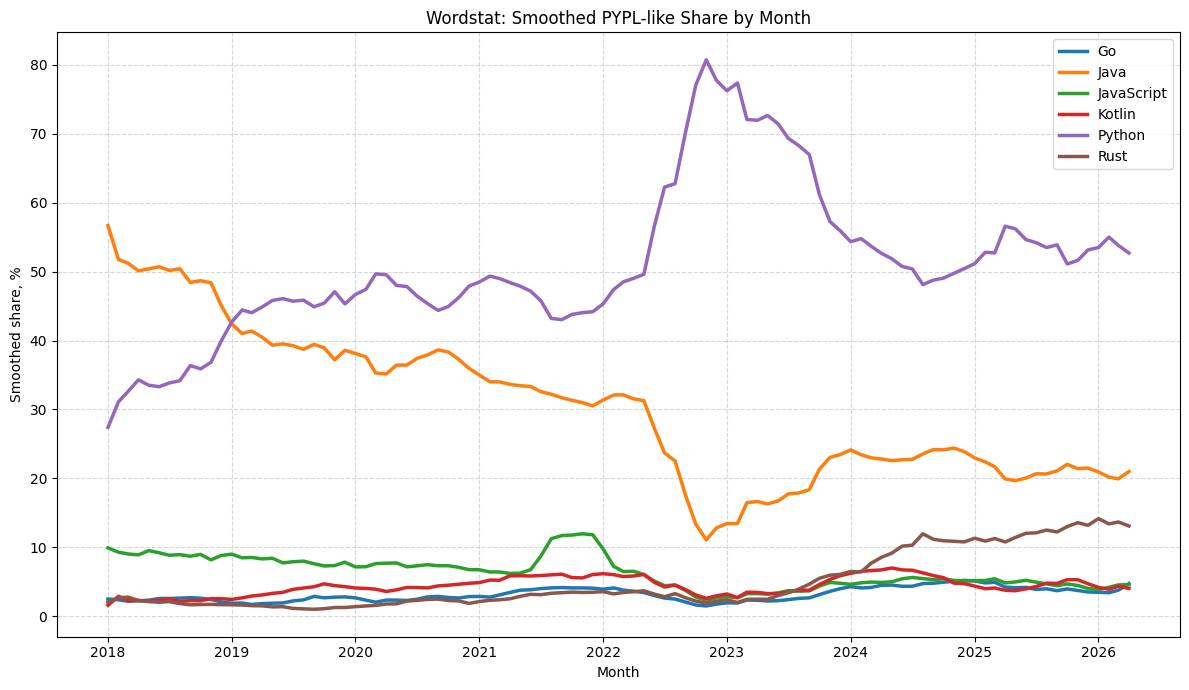

In [7]:
plt.figure(figsize=(12, 7))

for language in monthly_index_df["language"].unique():
    language_df = monthly_index_df[monthly_index_df["language"] == language]
    plt.plot(language_df["date"], language_df["smoothed_share_pct"], linewidth=2.5, label=language)

plt.title("Wordstat: Smoothed PYPL-like Share by Month")
plt.xlabel("Month")
plt.ylabel("Smoothed share, %")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Загрузка эталонных данных PYPL

Файл `pypl_reference.csv` содержит данные, полученные из таблицы PYPL.

In [8]:
pypl_df = pd.read_csv(PYPL_REFERENCE_PATH)
pypl_df["date"] = pd.to_datetime(pypl_df["date"])
pypl_df.head()

,date,Go,Java,JavaScript,Kotlin,Python,Rust
0,2004-06-01,0.0,29.8,9.3,0.0,2.1,0.0
1,2004-07-01,0.0,29.5,9.2,0.0,2.6,0.0
2,2004-08-01,0.0,29.5,9.2,0.0,2.7,0.0
3,2004-09-01,0.0,29.2,9.1,0.0,2.7,0.0
4,2004-10-01,0.0,29.0,8.9,0.0,2.8,0.0


## 10. Подготовка данных к сравнению

Оставляем общий период наблюдений и приводим оба источника к единому широкому формату.

In [9]:
wordstat_wide_df = monthly_index_df.pivot(index="date", columns="language", values="smoothed_share_pct").reset_index()

common_languages = ["Go", "Java", "JavaScript", "Kotlin", "Python", "Rust"]
comparison_df = wordstat_wide_df.merge(pypl_df, on="date", suffixes=("_wordstat", "_pypl"))
comparison_df = comparison_df.sort_values("date").reset_index(drop=True)

print(comparison_df.shape)
print(comparison_df.columns.tolist())
comparison_df.head()

(100, 13)
['date', 'Go_wordstat', 'Java_wordstat', 'JavaScript_wordstat', 'Kotlin_wordstat', 'Python_wordstat', 'Rust_wordstat', 'Go_pypl', 'Java_pypl', 'JavaScript_pypl', 'Kotlin_pypl', 'Python_pypl', 'Rust_pypl']


,date,Go_wordstat,Java_wordstat,JavaScript_wordstat,Kotlin_wordstat,Python_wordstat,Rust_wordstat,Go_pypl,Java_pypl,JavaScript_pypl,Kotlin_pypl,Python_pypl,Rust_pypl
0,2018-01-01,2.4725,56.6850,9.8901,1.5568,27.3810,2.0147,0.8,22.2,8.2,0.8,20.9,0.003
1,2018-02-01,2.3572,51.7612,9.2685,2.8601,31.1044,2.6486,0.8,21.9,8.3,0.8,21.4,0.003
2,2018-03-01,2.1433,51.2286,9.0113,2.2880,32.5827,2.7462,0.8,21.7,8.3,0.8,21.7,0.003
3,2018-04-01,2.2007,50.1164,8.8771,2.2668,34.2887,2.2503,0.9,21.6,8.4,0.9,22.2,0.003
4,2018-05-01,2.3024,50.4027,9.5010,2.1850,33.5146,2.0944,0.9,21.5,8.4,0.9,22.5,0.003


## 11. Графики рядом: Wordstat и PYPL

Теперь можно визуально сравнить сглаженный PYPL-like индекс и официальный PYPL на одном и том же периоде.

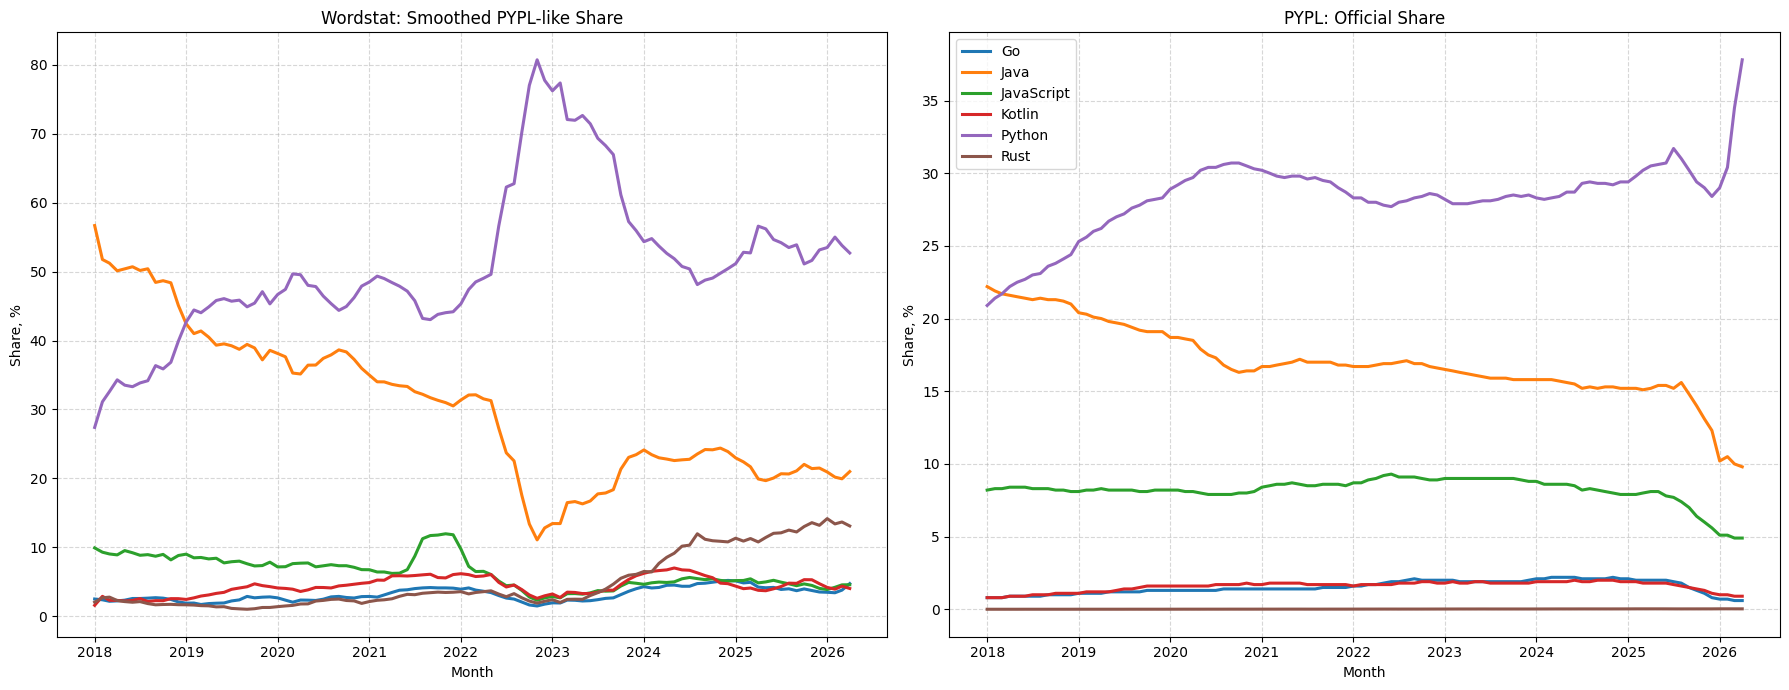

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

for language in common_languages:
    axes[0].plot(comparison_df["date"], comparison_df[f"{language}_wordstat"], linewidth=2.2, label=language)
    axes[1].plot(comparison_df["date"], comparison_df[f"{language}_pypl"], linewidth=2.2, label=language)

axes[0].set_title("Wordstat: Smoothed PYPL-like Share")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Share, %")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].set_title("PYPL: Official Share")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Share, %")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

## 12. Сравнение в логарифмической шкале

Официальный график PYPL визуально напоминает логарифмическую шкалу, поэтому полезно посмотреть и такое сравнение.

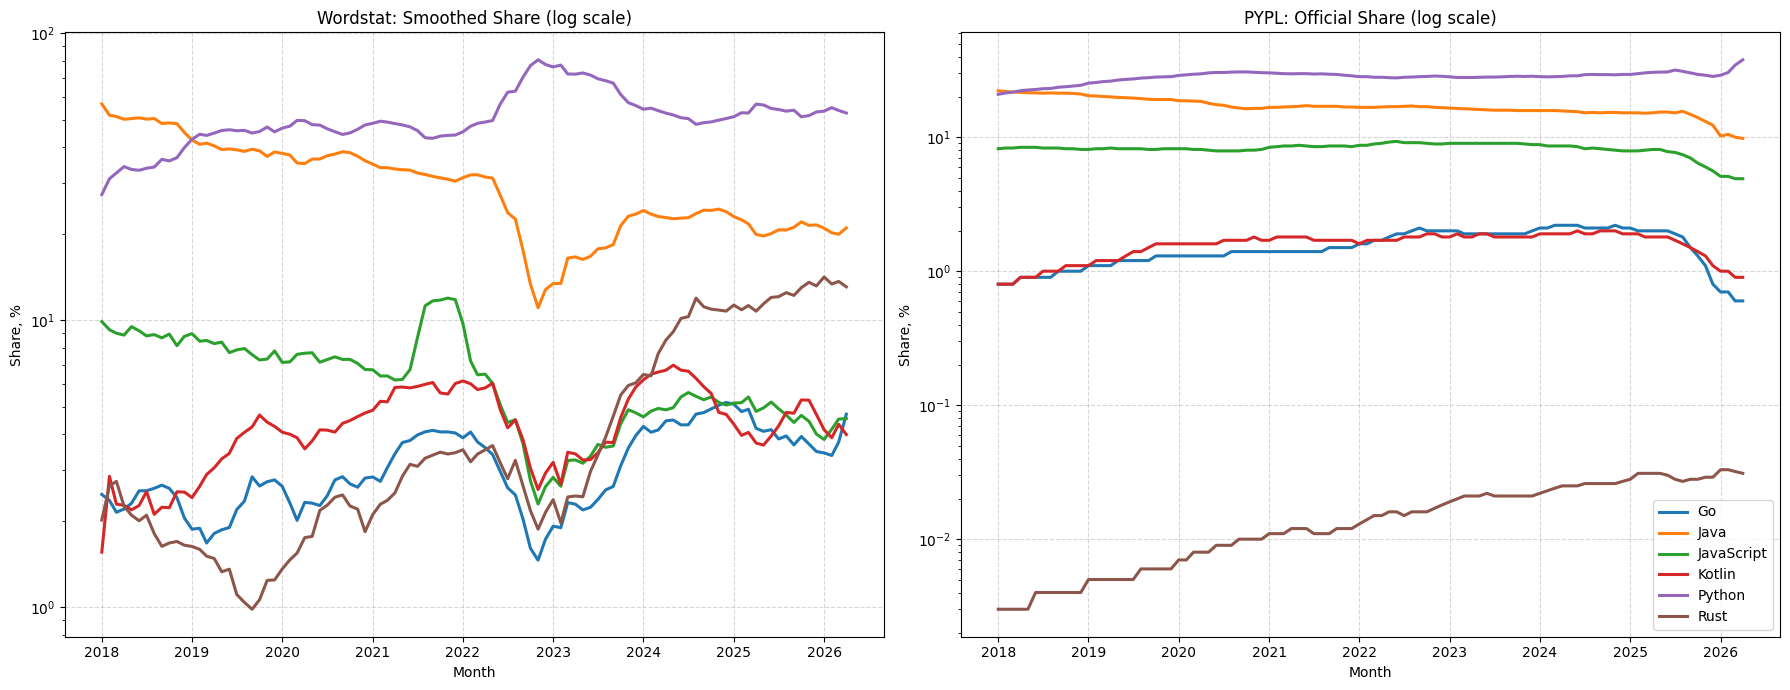

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

for language in common_languages:
    axes[0].plot(comparison_df["date"], comparison_df[f"{language}_wordstat"].clip(lower=0.001), linewidth=2.2, label=language)
    axes[1].plot(comparison_df["date"], comparison_df[f"{language}_pypl"].clip(lower=0.001), linewidth=2.2, label=language)

axes[0].set_title("Wordstat: Smoothed Share (log scale)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Share, %")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].set_title("PYPL: Official Share (log scale)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Share, %")
axes[1].set_yscale("log")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

## 13. Численное сравнение рядов

Помимо визуального анализа, рассчитываем численные показатели сходства:

- корреляцию Пирсона;
- ранговую корреляцию Спирмена;
- среднюю абсолютную ошибку между долями;
- разницу последнего значения.

In [12]:
rows = []

for language in common_languages:
    wordstat_series = comparison_df[f"{language}_wordstat"]
    pypl_series = comparison_df[f"{language}_pypl"]

    pearson_corr = wordstat_series.corr(pypl_series, method="pearson")
    spearman_corr = wordstat_series.corr(pypl_series, method="spearman")
    mae = (wordstat_series - pypl_series).abs().mean()
    latest_gap = wordstat_series.iloc[-1] - pypl_series.iloc[-1]

    rows.append(
        {
            "language": language,
            "pearson_corr": round(pearson_corr, 4),
            "spearman_corr": round(spearman_corr, 4),
            "mae_share_pct": round(mae, 4),
            "latest_gap_pct_points": round(latest_gap, 4),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("pearson_corr", ascending=False).reset_index(drop=True)
metrics_df

,language,pearson_corr,spearman_corr,mae_share_pct,latest_gap_pct_points
0,Rust,0.8864,0.8725,4.8921,13.0439
1,Java,0.7990,0.7939,13.6861,11.1727
2,Kotlin,0.5927,0.4679,2.7492,3.0989
3,Python,0.4134,0.2817,22.6063,14.9022
4,Go,0.3854,0.4411,1.6434,4.1075
5,JavaScript,0.0725,-0.1915,2.3602,-0.3563


## 14. Сравнение рангов языков по месяцам

Сравниваем, насколько близок порядок языков в Wordstat и PYPL в каждый месяц.

In [13]:
rank_rows = []
leader_matches = 0

for _, row in comparison_df.iterrows():
    wordstat_values = {language: row[f"{language}_wordstat"] for language in common_languages}
    pypl_values = {language: row[f"{language}_pypl"] for language in common_languages}

    wordstat_rank = pd.Series(wordstat_values).rank(ascending=False, method="average")
    pypl_rank = pd.Series(pypl_values).rank(ascending=False, method="average")
    rank_corr = wordstat_rank.corr(pypl_rank, method="spearman")

    wordstat_leader = max(wordstat_values, key=wordstat_values.get)
    pypl_leader = max(pypl_values, key=pypl_values.get)
    leader_match = wordstat_leader == pypl_leader
    if leader_match:
        leader_matches += 1

    rank_rows.append(
        {
            "date": row["date"],
            "rank_corr": rank_corr,
            "wordstat_leader": wordstat_leader,
            "pypl_leader": pypl_leader,
            "leader_match": leader_match,
        }
    )

rank_comparison_df = pd.DataFrame(rank_rows)
rank_comparison_df.head()

,date,rank_corr,wordstat_leader,pypl_leader,leader_match
0,2018-01-01,0.898645,Java,Java,True
1,2018-02-01,0.898645,Java,Java,True
2,2018-03-01,0.794461,Java,Java,True
3,2018-04-01,0.840668,Java,Python,False
4,2018-05-01,0.927634,Java,Python,False


In [14]:
rank_summary_df = pd.DataFrame(
    {
        "metric": [
            "Average monthly rank correlation",
            "Median monthly rank correlation",
            "Leader match ratio",
        ],
        "value": [
            round(rank_comparison_df["rank_corr"].mean(), 4),
            round(rank_comparison_df["rank_corr"].median(), 4),
            round(leader_matches / len(rank_comparison_df), 4),
        ],
    }
)
rank_summary_df

,metric,value
0,Average monthly rank correlation,0.8052
1,Median monthly rank correlation,0.8857
2,Leader match ratio,0.9100


## 15. Финальные выводы по сравнению с PYPL

Формируем краткое текстовое заключение по степени сходства между Wordstat и PYPL.

In [15]:
best_match_row = metrics_df.iloc[0]
worst_match_row = metrics_df.iloc[-1]
average_rank_corr = rank_comparison_df["rank_corr"].mean()
leader_match_ratio = leader_matches / len(rank_comparison_df)

print("Краткие выводы по сравнению с PYPL:")
print(
    f"- Наиболее близкий к PYPL по форме ряда язык: {best_match_row['language']} "
    f"(Pearson = {best_match_row['pearson_corr']}, Spearman = {best_match_row['spearman_corr']})."
)
print(
    f"- Наименее похожий язык: {worst_match_row['language']} "
    f"(Pearson = {worst_match_row['pearson_corr']}, Spearman = {worst_match_row['spearman_corr']})."
)
print(f"- Средняя ранговая корреляция по месяцам: {average_rank_corr:.4f}")
print(f"- Доля месяцев, в которых совпал язык-лидер: {leader_match_ratio:.2%}")
print("- Wordstat и PYPL можно сравнивать по форме динамики и по рангу языков, но не как полностью идентичные индексы.")
print("- Основные причины расхождений: другой источник данных, другая аудитория поиска и чувствительность к формулировке tutorial-запросов.")

Краткие выводы по сравнению с PYPL:
- Наиболее близкий к PYPL по форме ряда язык: Rust (Pearson = 0.8864, Spearman = 0.8725).
- Наименее похожий язык: JavaScript (Pearson = 0.0725, Spearman = -0.1915).
- Средняя ранговая корреляция по месяцам: 0.8052
- Доля месяцев, в которых совпал язык-лидер: 91.00%
- Wordstat и PYPL можно сравнивать по форме динамики и по рангу языков, но не как полностью идентичные индексы.
- Основные причины расхождений: другой источник данных, другая аудитория поиска и чувствительность к формулировке tutorial-запросов.
